In [1]:
import numpy as np
m = np.load("/content/drive/MyDrive/Pomona/2026/Rosetta_Commons/DrewLab/PDL1_l132_s267698_seqmatrix.npy")
print(m.shape)

(156, 132, 20)


In [2]:
type(m)

numpy.ndarray

In [3]:
m[0].shape

(132, 20)

In [4]:
m[20,:,6]

array([ 0.04303381,  0.27456152,  0.00769304,  0.46083185, -0.19931571,
        0.00352058, -0.07884586,  0.04676119, -0.122978  , -0.45889592,
        0.11657733, -0.25556535, -0.22220886, -0.15815343, -0.02989621,
       -0.05862633,  0.05200635,  0.11873627, -0.0087857 , -0.13822253,
       -0.07661163, -0.1748881 , -0.17044616, -0.20124152, -0.06148377,
       -0.27031025,  0.00433357, -0.17335007,  0.01803616, -0.01891091,
        0.06742543,  0.19693409, -0.19931628,  0.4200965 ,  0.01477057,
        0.35413375,  0.3846722 , -0.14626583,  0.04423138,  0.04426072,
       -0.24168374, -0.33619818, -0.19114521,  0.04692405, -0.03282103,
       -0.40626907,  0.03408563,  0.07946302, -0.04667197, -0.00464727,
        0.07511499, -0.1277404 , -0.40879074,  0.22667122, -0.00461675,
       -0.34842527, -0.19356401,  0.02444034, -0.14878173, -0.0758245 ,
       -0.23603764, -0.15208049,  0.20772195, -0.05655869, -0.37316597,
       -0.02724236,  0.91956896, -0.04922432, -0.08671951, -0.08

In [6]:
m[50,6,:]

array([ 0.39242923, -0.4753328 ,  0.22539128, -0.28247795, -0.41146383,
       -0.51324606,  0.06851134,  0.0457365 ,  0.36535078,  1.0301312 ,
       -0.01986206,  0.04976751,  0.6822847 ,  0.3442424 , -0.33792418,
        0.07698753, -0.4300532 , -0.13139273,  0.9563173 ], dtype=float32)

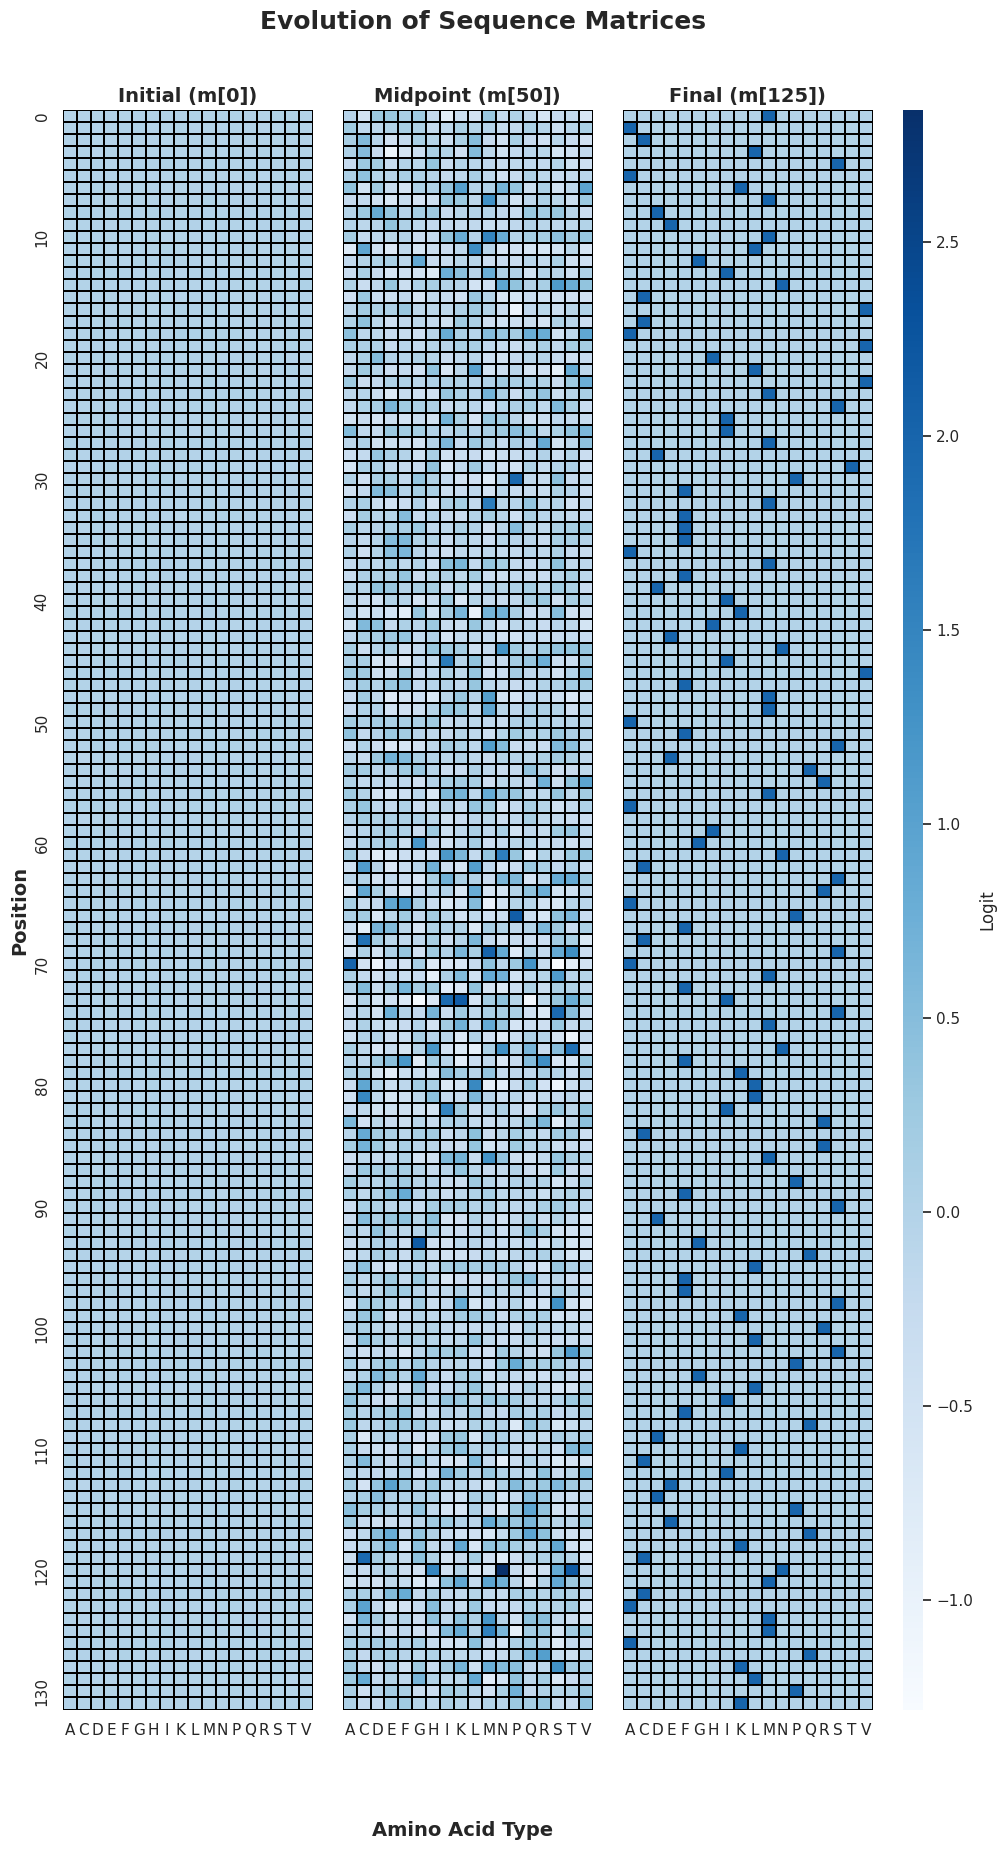

<Figure size 640x480 with 0 Axes>

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Prepare indices and titles
indices = [0, 50, 125]
titles = ["Initial (m[0])", "Midpoint (m[50])", "Final (m[125])"]
amino_acids = ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']

# Global min/max for scale consistency
val_min = min(m[0].min(), m[50].min(), m[-1].min())
val_max = max(m[0].max(), m[50].max(), m[-1].max())

fig = plt.figure(figsize=(10, 20))

# Define explicit coordinates [left, bottom, width, height] to enforce identical widths
# Each plot gets 0.25 width, separated by 0.03 gaps
plot_width = 0.25
plot_height = 0.8
start_y = 0.1
positions = [[0.08, start_y, plot_width, plot_height],
             [0.36, start_y, plot_width, plot_height],
             [0.64, start_y, plot_width, plot_height]]

# Independent colorbar axis on the far right so it doesn't affect subplot widths
cbar_ax = fig.add_axes([0.92, start_y, 0.02, plot_height])

for i, idx in enumerate(indices):
    ax = fig.add_axes(positions[i])
    sns.heatmap(
        m[idx],
        ax=ax,
        xticklabels=amino_acids[:m.shape[2]],
        yticklabels=10,
        cmap="Blues",
        vmin=val_min,
        vmax=val_max,
        linewidths=0.1,
        linecolor='black',
        cbar=(i == 2),
        cbar_ax=cbar_ax if i == 2 else None,
        cbar_kws={'label': 'Logit'} if i == 2 else None
    )
    ax.set_title(titles[i], fontsize=14, fontweight='bold')

    if i > 0:
        ax.set_yticklabels([]) # Hide y-labels for 2nd and 3rd plot
    else:
        ax.set_ylabel("Position", fontsize=14, fontweight='bold')

# Add shared x-label at the bottom
fig.text(0.48, 0.04, 'Amino Acid Type', ha='center', va='center', fontsize=14, fontweight='bold')
plt.suptitle("Evolution of Sequence Matrices", fontsize=18, y=0.95,  fontweight='bold')

plt.show()
plt.savefig('01_seqmatrix_heatmap_by_iteration.png', dpi=600, bbox_inches='tight')

<Axes: >

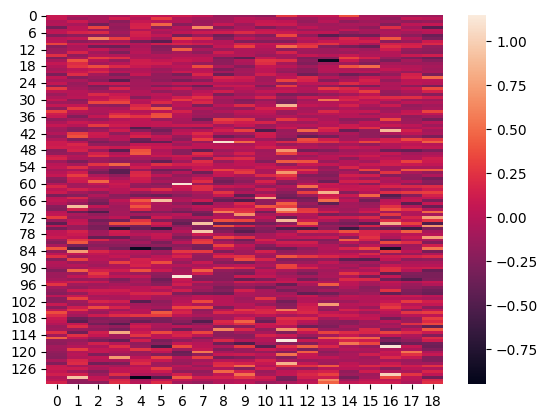

In [7]:
sns.heatmap(m[20])

<Axes: >

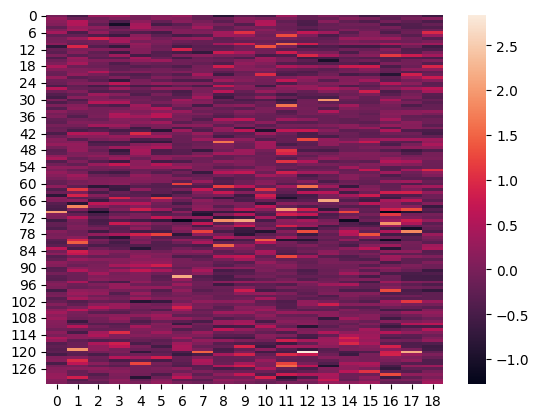

In [ ]:
sns.heatmap(m[50])

<Axes: >

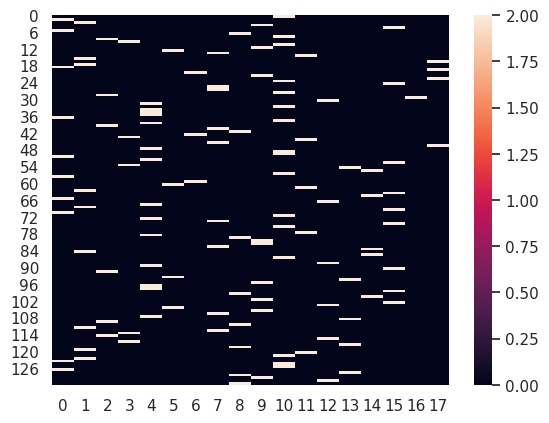

In [56]:
sns.heatmap(m[125])

In [8]:
sequence = 'MARKRALMNDMKGIFRVRAVPKVMWIIMNYPEMEEEAMENILHDFIVEMMAEWDSTMAQHGFRWTAPERWAMEIWMQFELKKITRTMQPEWNQGSKEEWLTKWPGKIESNLRIDNPDSLRFMRAMMASLKPV'
seq = [i for i in sequence]

In [9]:
interface_residue = [34, 35, 38, 64, 65, 66, 67, 69, 70, 73, 74, 76, 77, 78, 80, 81, 84, 114, 115, 116, 117, 119, 120, 123, 124, 126, 127]

In [10]:
[i+1 for i in interface_residue]

[35,
 36,
 39,
 65,
 66,
 67,
 68,
 70,
 71,
 74,
 75,
 77,
 78,
 79,
 81,
 82,
 85,
 115,
 116,
 117,
 118,
 120,
 121,
 124,
 125,
 127,
 128]

B35,B36,B39,B66,B67,B68,B70,B71,B74,B75,B77,B78,B79,B81,B82,B85,B117,B118,B120,B121,B124,B125,B127,B128

B35,B36,B39,B67,B68,B70,B71,B74,B75,B77,B78,B81,B82,B85,B112,B117,B118,B120,B121,B124,B127,B128

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, clear_output

# m, seq, interface_residue are defined in previous cells
# m.shape is (156, 132, 19) after the delete operation.
# seq is a list of 132 characters.

def plot_interactive_heatmaps(index):
    clear_output(wait=True) # Clear previous plot

    # Ensure index and index+1 are within bounds for displaying two heatmaps
    if index < 0 or index >= m.shape[0] - 1:
        print(f"Please select an index between 0 and {m.shape[0] - 2} for valid comparison.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(25, 20)) # Two subplots side-by-side, adjusted figsize for better view

    num_cols = m.shape[2] # All m[i] will have the same number of columns (19)
    num_rows = m.shape[1] # All m[i] will have the same number of rows (132)

    # Calculate global min and max for consistent color scaling across both heatmaps
    global_min = min(m[index].min(), m[index + 1].min())
    global_max = max(m[index].max(), m[index + 1].max())

    # Plot first heatmap (m[index])
    sns.heatmap(m[index], annot=True, yticklabels=seq, ax=axes[0], fmt=".2f", cmap='viridis', cbar=False, vmin=global_min, vmax=global_max)
    axes[0].set_title(f'Heatmap for m[{index}]', fontsize=16)
    axes[0].tick_params(labelsize=10)

    for row_idx in interface_residue:
        if 0 <= row_idx < num_rows:
            rect = patches.Rectangle((0, row_idx), width=num_cols, height=1,
                                     edgecolor='blue', facecolor='none', lw=3)
            axes[0].add_patch(rect)

    # Plot second heatmap (m[index + 1])
    sns.heatmap(m[index + 1], annot=True, yticklabels=seq, ax=axes[1], fmt=".2f", cmap='viridis', cbar=False, vmin=global_min, vmax=global_max)
    axes[1].set_title(f'Heatmap for m[{index + 1}]', fontsize=16)
    axes[1].tick_params(labelsize=10)

    for row_idx in interface_residue:
        if 0 <= row_idx < num_rows:
            rect = patches.Rectangle((0, row_idx), width=num_cols, height=1,
                                     edgecolor='blue', facecolor='none', lw=3)
            axes[1].add_patch(rect)

    plt.tight_layout()
    plt.show()

# Create a slider widget for the index
# The max value should be m.shape[0] - 2 to allow m[index+1] to be valid
index_slider = widgets.IntSlider(
    value=0, # Start at the first index
    min=0,
    max=m.shape[0] - 2, # Max index for the first heatmap to ensure m[index+1] is valid (156 - 2 = 154)
    step=1,
    description='Matrix Index:'
)

# Use interactive to link the slider to the plotting function
# Display the widget and the output of the interactive function
display(widgets.interactive(plot_interactive_heatmaps, index=index_slider))

interactive(children=(IntSlider(value=0, description='Matrix Index:', max=154), Output()), _dom_classes=('widg…

In [12]:
sum(m[125] == m[127])

array([132, 132, 132, 132, 131, 132, 132, 132, 132, 132, 132, 132, 132,
       131, 132, 132, 132, 132, 132])

In [13]:
sum(m[124,131,:])

np.float32(1.4298005)

In [14]:
def softmax(x):
    """Compute softmax values for each sets of scores in x."""
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum(axis=0)

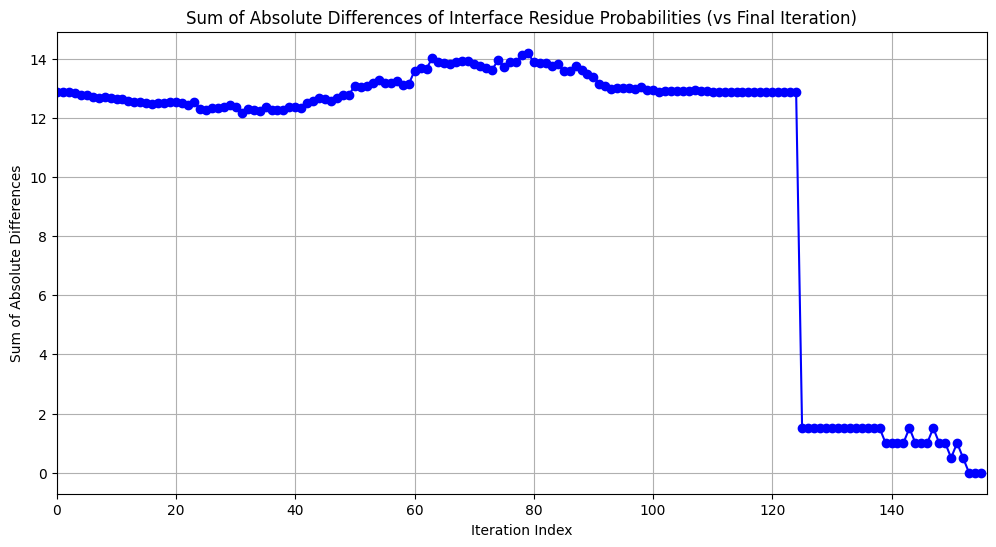

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Using Absolute Differences to see magnitude of change
distances = []
num_iterations = m.shape[0]

for i in range(num_iterations):
    # Extract interface rows
    rows_current_raw = m[i, interface_residue, :]
    rows_final_raw = m[-1, interface_residue, :]

    # Apply softmax to change them to probabilities along the feature axis
    rows_current_prob = np.array([softmax(row) for row in rows_current_raw])
    rows_final_prob = np.array([softmax(row) for row in rows_final_raw])

    # Compute the sum of ABSOLUTE differences (L1 Norm)
    # This prevents values from canceling each other out to zero
    diff = np.abs(rows_current_prob - rows_final_prob)
    total_diff_sum = np.sum(diff)
    distances.append(total_diff_sum)

# Plotting the results
plt.figure(figsize=(12, 6))
plt.plot(range(len(distances)), distances, marker='o', linestyle='-', color='b')
plt.title('Sum of Absolute Differences of Interface Residue Probabilities (vs Final Iteration)')
plt.xlabel('Iteration Index')
plt.ylabel('Sum of Absolute Differences')
plt.xlim(0, num_iterations)
plt.grid(True)
plt.show()

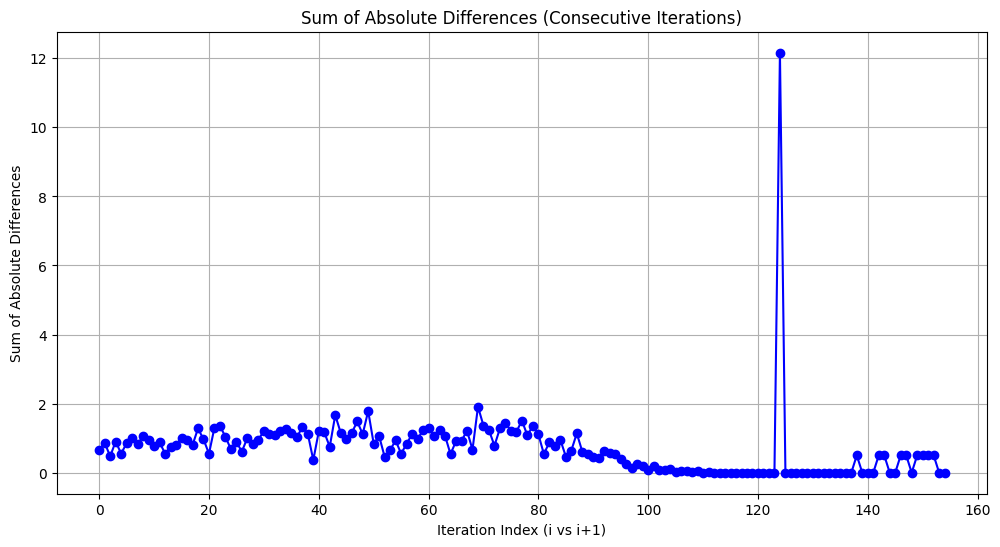

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

distances = []
num_iterations = m.shape[0]

# Loop through iterations to calculate distance between consecutive iterations (i vs i+1)
for i in range(num_iterations - 1):
    # Extract interface rows for i and i+1
    rows_current_raw = m[i, interface_residue, :]
    rows_next_raw = m[i+1, interface_residue, :]

    # Apply softmax to change them to probabilities along the feature axis
    rows_current_prob = np.array([softmax(row) for row in rows_current_raw])
    rows_next_prob = np.array([softmax(row) for row in rows_next_raw])

    # Compute the sum of ABSOLUTE differences (L1 Norm) between consecutive states
    diff = np.abs(rows_current_prob - rows_next_prob)
    total_diff_sum = np.sum(diff)
    distances.append(total_diff_sum)

# Plotting the results
plt.figure(figsize=(12, 6))
plt.plot(range(len(distances)), distances, marker='o', linestyle='-', color='b')
plt.title('Sum of Absolute Differences (Consecutive Iterations)')
plt.xlabel('Iteration Index (i vs i+1)')
plt.ylabel('Sum of Absolute Differences')
plt.grid(True)
plt.show()

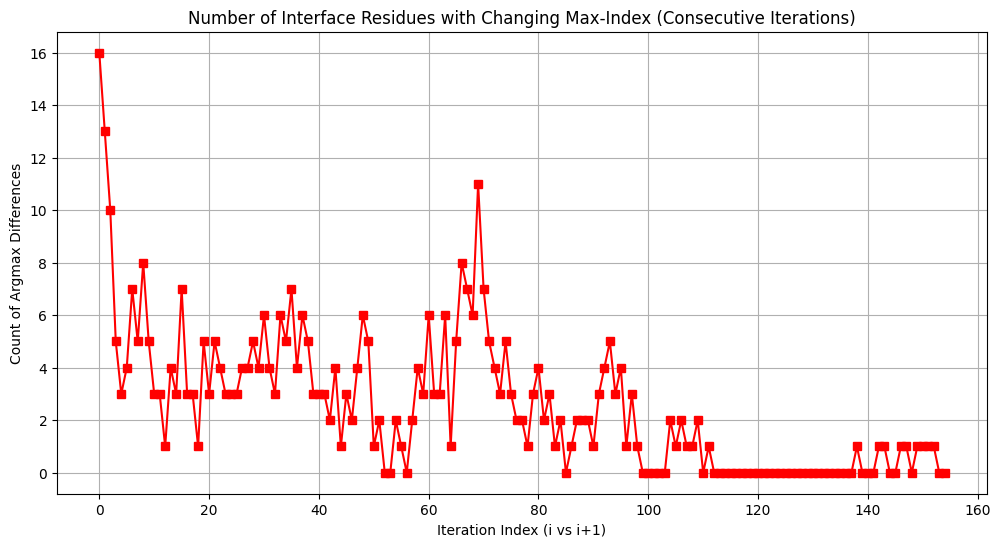

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

argmax_changes = []
num_iterations = m.shape[0]

# Loop through consecutive iterations
for i in range(num_iterations - 1):
    # Extract interface rows for i and i+1
    rows_current = m[i, interface_residue, :]
    rows_next = m[i+1, interface_residue, :]

    # Get the index of the maximum value for each row
    idx_current = np.argmax(rows_current, axis=1)
    idx_next = np.argmax(rows_next, axis=1)

    # Count how many positions have a different argmax index
    # (index are not the same -> count + 1)
    num_changes = np.sum(idx_current != idx_next)
    argmax_changes.append(num_changes)

# Plotting the results
plt.figure(figsize=(12, 6))
plt.plot(range(len(argmax_changes)), argmax_changes, marker='s', linestyle='-', color='red')
plt.title('Number of Interface Residues with Changing Max-Index (Consecutive Iterations)')
plt.xlabel('Iteration Index (i vs i+1)')
plt.ylabel('Count of Argmax Differences')
plt.grid(True)
plt.show()

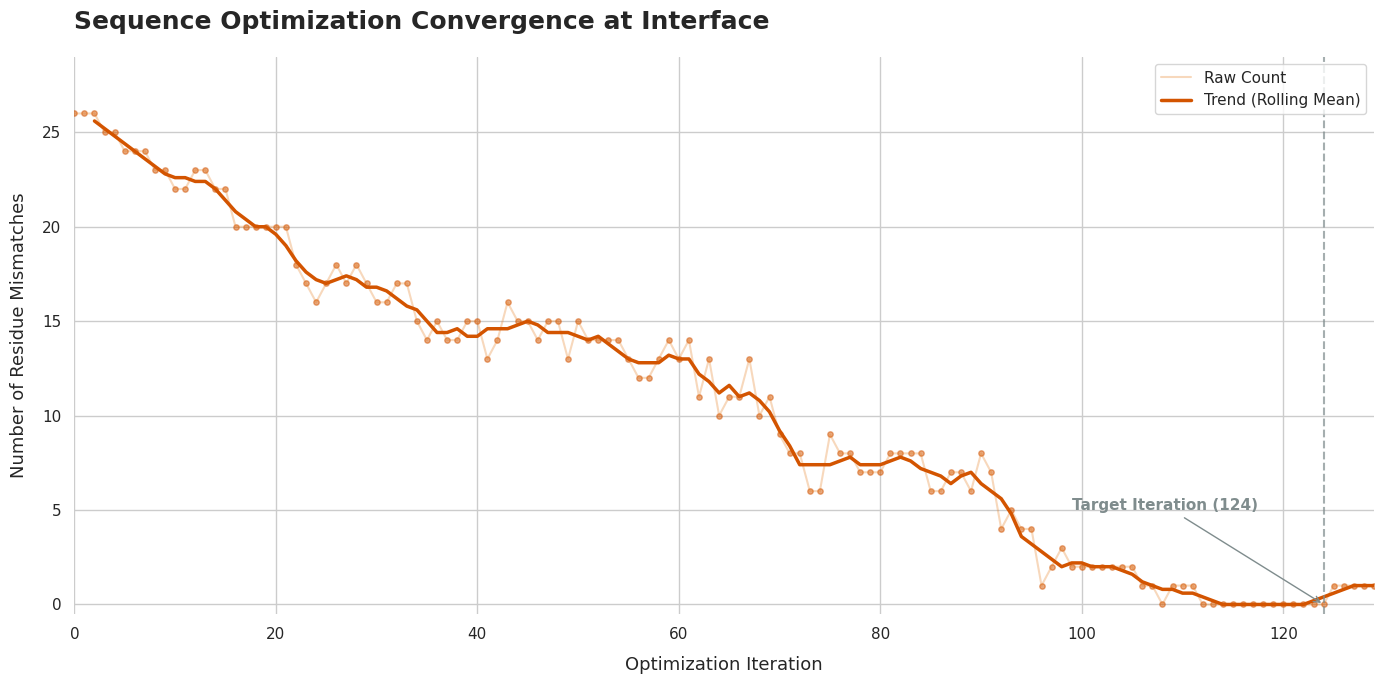

In [64]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calculate differences
argmax_changes = []
num_iterations = m.shape[0]
comparison_idx = 124

for i in range(num_iterations):
    rows_current = m[i, interface_residue, :]
    rows_final = m[comparison_idx, interface_residue, :]
    idx_current = np.argmax(rows_current, axis=1)
    idx_final = np.argmax(rows_final, axis=1)
    argmax_changes.append(np.sum(idx_current != idx_final))

# Prepare data for plotting
df = pd.DataFrame({'Iteration': range(len(argmax_changes)), 'Differences': argmax_changes})
df['Rolling_Avg'] = df['Differences'].rolling(window=5, center=True).mean()

# Styling
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7), dpi=100)

# Main plot
plt.plot(df['Iteration'], df['Differences'], color='#E67E22', alpha=0.3, label='Raw Count')
plt.plot(df['Iteration'], df['Rolling_Avg'], color='#D35400', linewidth=2.5, label='Trend (Rolling Mean)')
plt.scatter(df['Iteration'], df['Differences'], color='#D35400', s=15, alpha=0.5)

# Formatting
plt.title('Sequence Optimization Convergence at Interface', fontsize=18, fontweight='bold', loc='left', pad=20)
plt.xlabel('Optimization Iteration', fontsize=13, labelpad=10)
plt.ylabel('Number of Residue Mismatches', fontsize=13, labelpad=10)

# Highlight the convergence target
plt.axvline(x=comparison_idx, color='#7F8C8D', linestyle='--', linewidth=1.5, alpha=0.7)
plt.annotate(f'Target Iteration ({comparison_idx})', xy=(comparison_idx, 0), xytext=(comparison_idx-25, 5),
             arrowprops=dict(arrowstyle='->', color='#7F8C8D'), fontsize=11, fontweight='bold', color='#7F8C8D')

plt.xlim(0, comparison_idx + 5)
plt.ylim(-0.5, len(interface_residue) + 2)
plt.legend(frameon=True, facecolor='white', loc='upper right')

# Clean up spines
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.savefig('01_interface_argmax_mismatch_count.png', dpi=300, bbox_inches='tight')
plt.show()

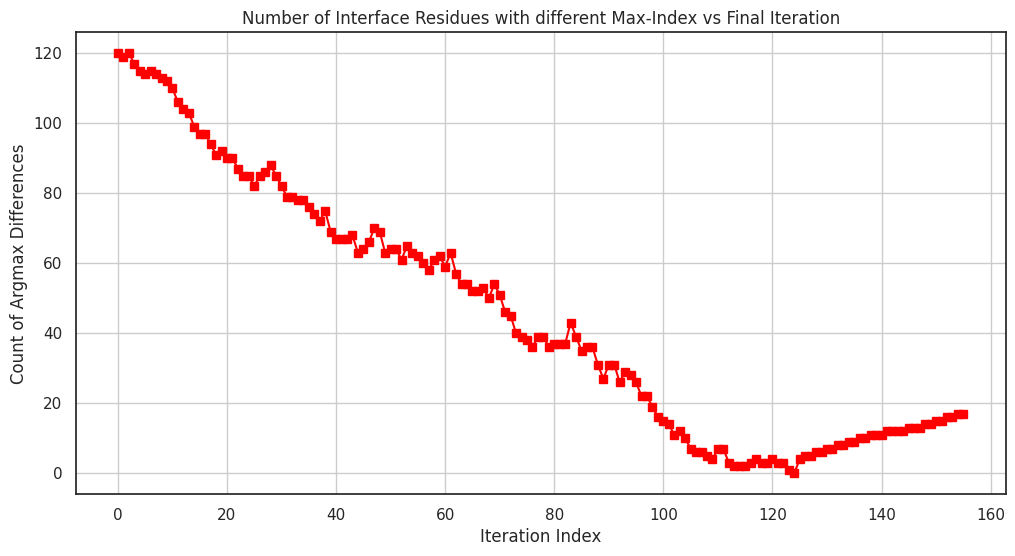

In [57]:
import numpy as np
import matplotlib.pyplot as plt

argmax_changes = []
num_iterations = m.shape[0]

# Loop through iterations to compare with the LAST iteration
for i in range(num_iterations):
    # Extract interface rows for current iteration and the absolute last iteration
    rows_current = m[i, :, :]
    rows_final = m[124,:, :]

    # Get the index of the maximum value for each row
    idx_current = np.argmax(rows_current, axis=1)
    idx_final = np.argmax(rows_final, axis=1)

    # Count how many positions have a different argmax index compared to the final state
    num_changes = np.sum(idx_current != idx_final)
    argmax_changes.append(num_changes)

# Plotting the results
plt.figure(figsize=(12, 6))
plt.plot(range(len(argmax_changes)), argmax_changes, marker='s', linestyle='-', color='red')
plt.title('Number of Interface Residues with different Max-Index vs Final Iteration')
plt.xlabel('Iteration Index')
plt.ylabel('Count of Argmax Differences')
plt.grid(True)
plt.show()